In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from adj import main, combine_graph_dict
from train import train_model
from utils import mclust_R, fix_seed

In [2]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score
from sklearn.metrics import v_measure_score as v_score
from utils import compute_PAS, compute_CHAOS
from sklearn.decomposition import PCA

In [3]:
fix_seed(1)

In [4]:
data_root = Path('../data/Mouse_Embryo')

proj_list = [
    'E9.5_E1S1.MOSTA', 'E9.5_E2S1.MOSTA', 'E9.5_E2S2.MOSTA', 'E9.5_E2S3.MOSTA', 'E9.5_E2S4.MOSTA'
]

#12, 14, 13, 13, 13

In [5]:
for proj_name in tqdm(proj_list):
    adata_tmp = sc.read_h5ad(os.path.join(data_root, proj_name + '.h5ad'))
    #print(len(adata_tmp.obs))
    adata_tmp.var_names_make_unique()

    adata_tmp.obs['batch_name'] = proj_name
    graph_dict_tmp = main(adata_tmp, adj_cons_by='coordinate', distType='KNN', k_cutoff=8, rad_cutoff=250)
    
    ##### Load layer_guess label, if have
    # df_label = pd.read_csv(data_root / proj_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_label.columns = ['layer_guess']
    # adata_tmp.obs['layer_guess'] = df_label['layer_guess']
    #adata_tmp= adata_tmp[~pd.isnull(adata_tmp.obs['layer_guess'])]
    
    if proj_name == proj_list[0]:
        adata = adata_tmp
        graph_dict = graph_dict_tmp
        name = proj_name
        adata.obs['proj_name'] = proj_name
    else:
        var_names = adata.var_names.intersection(adata_tmp.var_names)
        adata = adata[:, var_names]
        adata_tmp = adata_tmp[:, var_names]
        adata_tmp.obs['proj_name'] = proj_name
    
        adata = adata.concatenate(adata_tmp)
        graph_dict = combine_graph_dict(graph_dict, graph_dict_tmp)
        name = name + '_' + proj_name

  0%|          | 0/5 [00:00<?, ?it/s]

5913
------Calculating spatial graph...
The graph contains 47304 edges, 5913 cells.
8.0000 neighbors per cell on average.


 20%|██        | 1/5 [00:01<00:06,  1.66s/it]

5292
------Calculating spatial graph...
The graph contains 42336 edges, 5292 cells.
8.0000 neighbors per cell on average.


 40%|████      | 2/5 [00:05<00:07,  2.65s/it]

...

 60%|██████    | 3/5 [00:08<00:06,  3.19s/it]

5059
------Calculating spatial graph...
The graph contains 40472 edges, 5059 cells.
8.0000 neighbors per cell on average.


 80%|████████  | 4/5 [00:14<00:04,  4.09s/it]

5797
------Calculating spatial graph...
The graph contains 46376 edges, 5797 cells.
8.0000 neighbors per cell on average.


100%|██████████| 5/5 [00:20<00:00,  4.16s/it]


In [6]:
adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=3000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [ ]:
SpaBatch_net = train_model(adata, graph_dict, pre_epochs=400 ,epochs=500, mask_rate=0.2)
using_dec = True
if using_dec:
    SpaBatch_net.train_with_dec(num_aggre=1)
else:
    SpaBatch_net.train_without_dec()

Epoch 9 total loss=5969746156207472640.000:   2%|▎          [ time left: 02:07 ]     

In [ ]:
SpaBatch_feat, _ = SpaBatch_net.process()
adata.obsm['SpaBatch'] = SpaBatch_feat

In [ ]:
mclust_R(adata, num_cluster=13, used_obsm='SpaBatch')

In [ ]:
#adata.write("Ours_DLPFC_MOE1")

In [7]:
adata = sc.read_h5ad('Ours_DLPFC_MOE1')

In [7]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")

total ARI:0.3082775353428628
E9.5_E1S1.MOSTA ARI:0.21919796538162878
E9.5_E2S1.MOSTA ARI:0.2905319948299024
E9.5_E2S2.MOSTA ARI:0.4743323186130384
E9.5_E2S3.MOSTA ARI:0.42502389451184536
E9.5_E2S4.MOSTA ARI:0.44132109549377035


In [8]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total AMI:{AMI}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    AMI = ami_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    ACC = 1/2 * (NMI + AMI)
    print(f"{name} ACC:{ACC}")

total NMI:0.48568451490098047
total AMI:0.48489730681832
E9.5_E1S1.MOSTA ACC:0.43020652831976236
E9.5_E2S1.MOSTA ACC:0.540356243814488
E9.5_E2S2.MOSTA ACC:0.6069570345130534
E9.5_E2S3.MOSTA ACC:0.5902376878094987
E9.5_E2S4.MOSTA ACC:0.5845433706857339


In [9]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total COM:{COM}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    COM = com_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    V =  2 * ((HOM * COM) / (HOM + COM))
    print(f"{name} V:{V}")

total HOM:0.47444319033979787
total COM:0.49747146497546907
E9.5_E1S1.MOSTA V:0.4319786568135126
E9.5_E2S1.MOSTA V:0.541748001970331
E9.5_E2S2.MOSTA V:0.6082770489192367
E9.5_E2S3.MOSTA V:0.5913546975413737
E9.5_E2S4.MOSTA V:0.5855621882427499


1.6153840562218829
1.3463204679985559


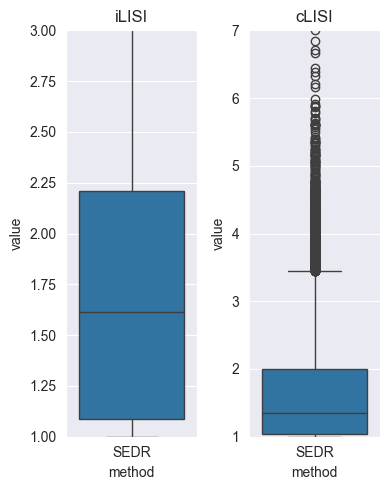

In [10]:
import harmonypy as hm

iLISI = hm.compute_lisi(adata.obsm['SpaBatch'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
cLISI = hm.compute_lisi(adata.obsm['SpaBatch'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]
df_iLISI = pd.DataFrame({
    'method': 'SpaBatch',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

df_cLISI = pd.DataFrame({
    'method': 'SpaBatch',
    'value': cLISI,
    'type': ['CLISI'] * len(cLISI)
})

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
print(np.median(cLISI))

In [1]:
# import matplotlib.pyplot as plt
# 
# plt.figure(figsize=(11, 10))
# k = 1
# spot_size = 2
# for slice_id, slice_name in enumerate(proj_list):
#     adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
#     ax = plt.subplot(2, 4, k)
#     # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
#     sc.pl.spatial(adata_tmp, img_key=None, color=['annotation'], title=[''],
#                   legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
#                   spot_size=spot_size)
#     plt.title(f'{slice_name}')
#     k += 1
# plt.tight_layout()

In [7]:
adata = sc.read_h5ad('Ours_DLPFC_MOE1')

proj_list = [
    'E9.5_E1S1.MOSTA', 'E9.5_E2S1.MOSTA', 'E9.5_E2S2.MOSTA', 'E9.5_E2S3.MOSTA', 'E9.5_E2S4.MOSTA'
]

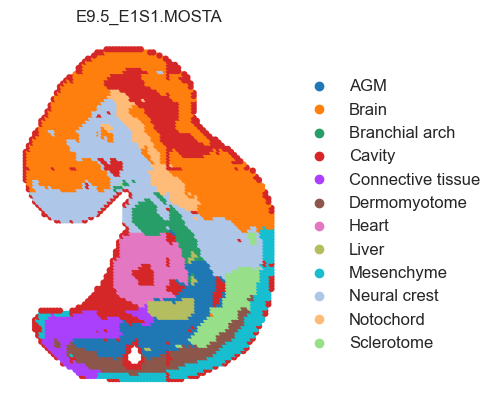

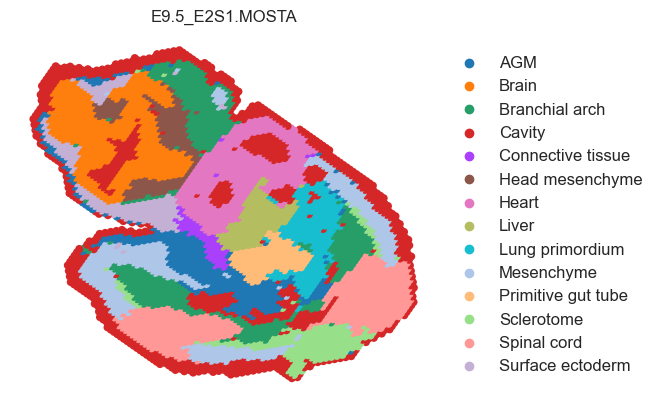

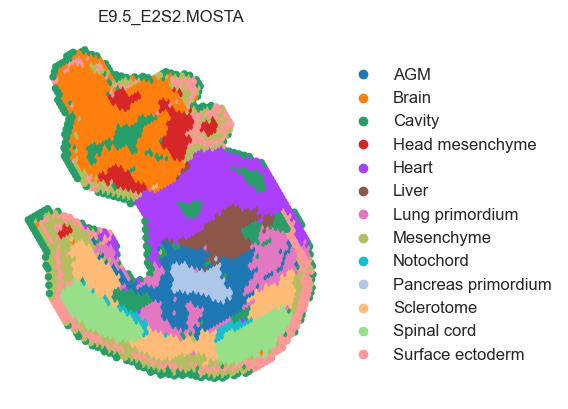

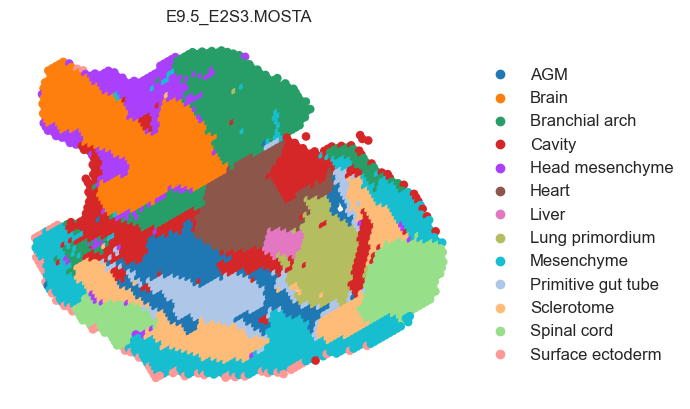

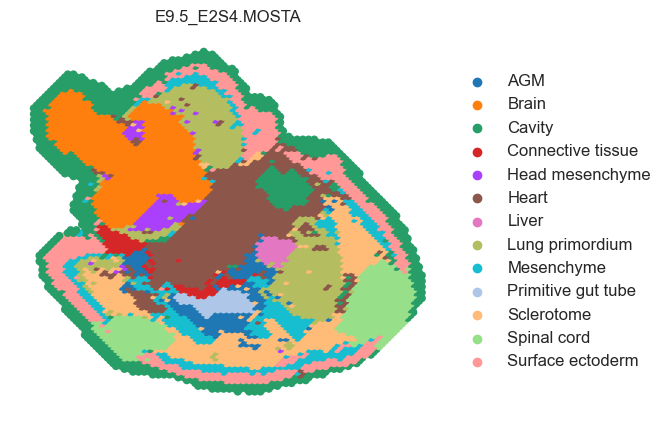

In [8]:
import matplotlib.pyplot as plt

spot_size = 2
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['annotation'], title=[''],
                  legend_loc='right margin', legend_fontsize=12, show=False, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
plt.tight_layout()

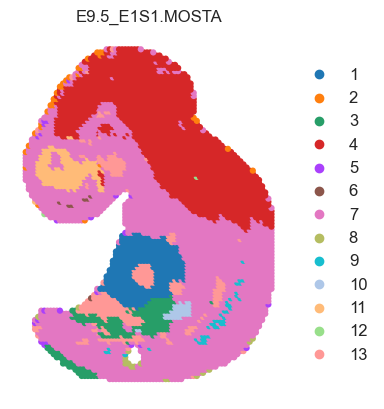

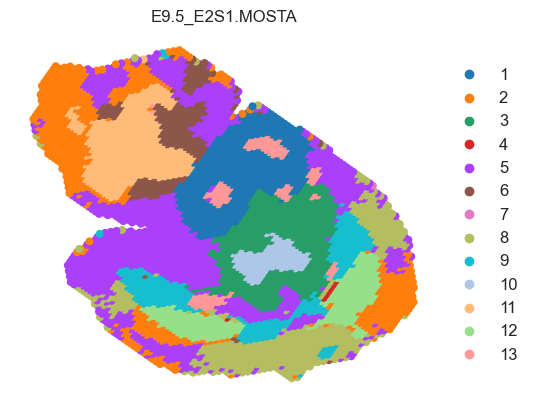

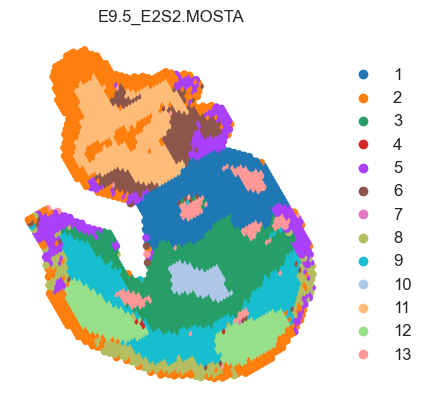

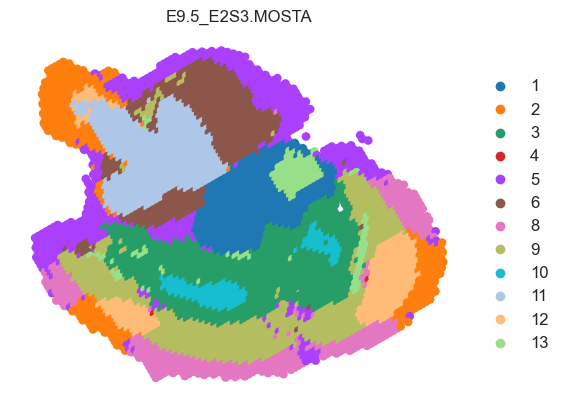

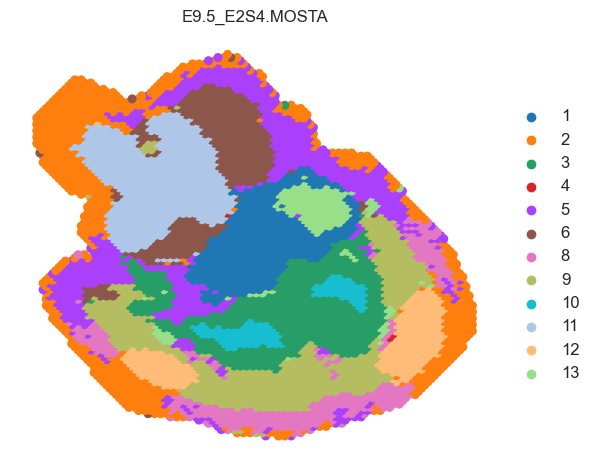

In [6]:
import matplotlib.pyplot as plt

spot_size = 2
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=12, show=False, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
plt.tight_layout()

In [9]:
plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色

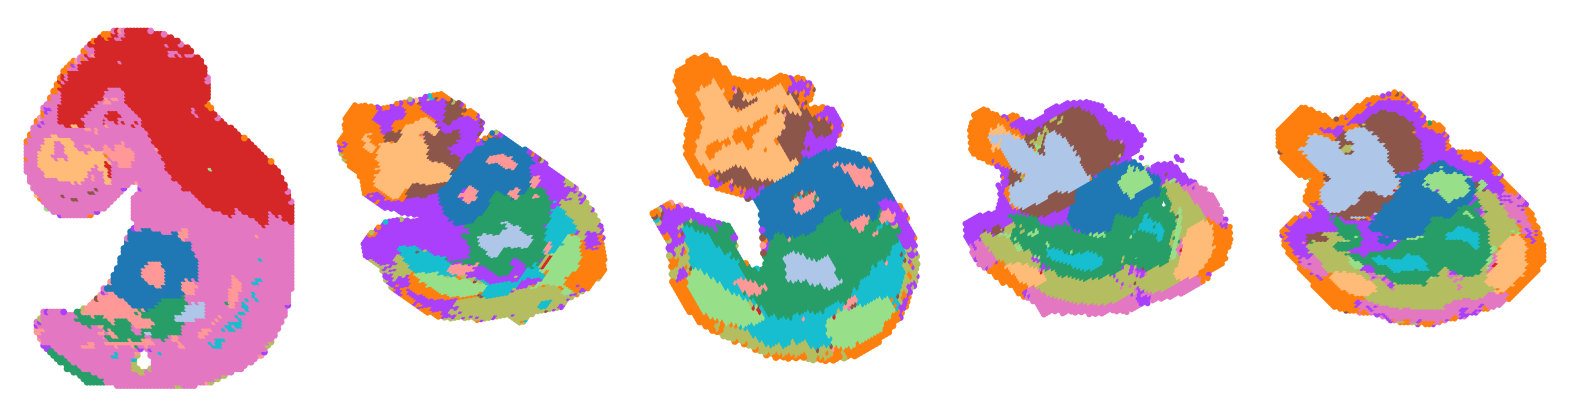

In [10]:
Batch_list = []
for section_id in proj_list:
    Batch_list.append(adata[adata.obs['batch_name'] == section_id])

fig, ax = plt.subplots(1, 5, figsize=(20, 10), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
_sc_0 = sc.pl.spatial(Batch_list[0], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[0], frameon=False,
                      spot_size=spot_size)
#_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=title_size)
_sc_1 = sc.pl.spatial(Batch_list[1], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[1], frameon=False,
                      spot_size=spot_size)
#_sc_1[0].set_title("ARI=" + str(ARI_list[1]), size=title_size)
_sc_2 = sc.pl.spatial(Batch_list[2], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[2], frameon=False,
                      spot_size=spot_size)
#[0].set_title("ARI=" + str(ARI_list[2]), size=title_size)
_sc_3 = sc.pl.spatial(Batch_list[3], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[3], frameon=False,
                      spot_size=spot_size)
#_sc_3[0].set_title("ARI=" + str(ARI_list[3]), size=title_size)
_sc_4 = sc.pl.spatial(Batch_list[4], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[4], frameon=False,
                      spot_size=spot_size)
#_sc_4[0].set_title("ARI=" + str(ARI_list[4]), size=title_size)
plt.show()

['Cavity', 'Mesenchyme', 'Connective tissue', 'Dermomyotome', 'AGM', ..., 'Brain', 'Heart', 'Branchial arch', 'Neural crest', 'Notochord']
Length: 12
Categories (12, object): ['AGM', 'Brain', 'Branchial arch', 'Cavity', ..., 'Mesenchyme', 'Neural crest', 'Notochord', 'Sclerotome']
[7, 8, 3, 13, 9, ..., 6, 4, 2, 12, 11]
Length: 13
Categories (13, int64): [1, 2, 3, 4, ..., 10, 11, 12, 13]


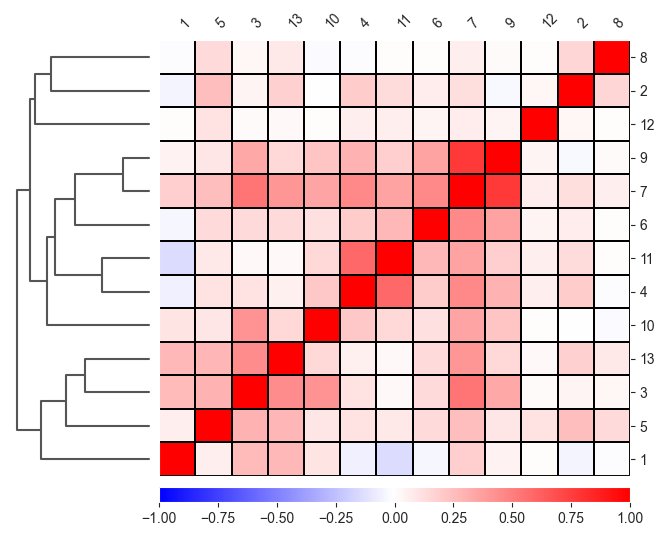

['Cavity', 'Spinal cord', 'Sclerotome', 'AGM', 'Mesenchyme', ..., 'Heart', 'Connective tissue', 'Surface ectoderm', 'Head mesenchyme', 'Brain']
Length: 14
Categories (14, object): ['AGM', 'Brain', 'Branchial arch', 'Cavity', ..., 'Primitive gut tube', 'Sclerotome', 'Spinal cord', 'Surface ectoderm']
[8, 2, 5, 12, 6, ..., 13, 7, 10, 1, 11]
Length: 13
Categories (13, int64): [1, 2, 3, 4, ..., 10, 11, 12, 13]


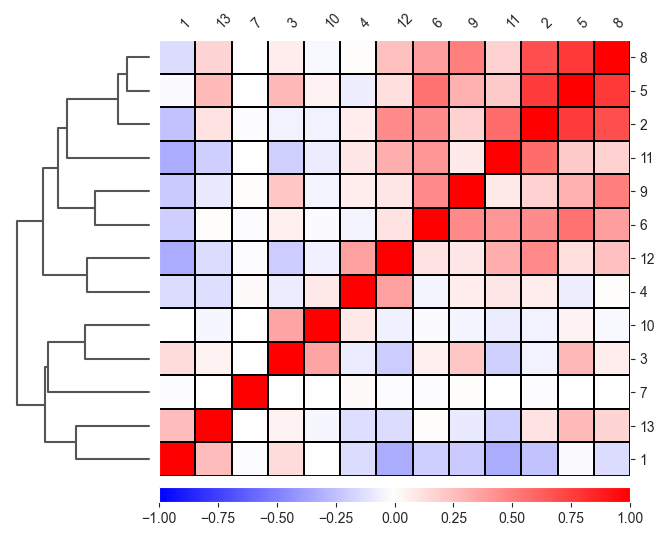

['Cavity', 'Surface ectoderm', 'Lung primordium', 'Heart', 'Mesenchyme', ..., 'Brain', 'Sclerotome', 'Spinal cord', 'Notochord', 'Pancreas primordium']
Length: 13
Categories (13, object): ['AGM', 'Brain', 'Cavity', 'Head mesenchyme', ..., 'Pancreas primordium', 'Sclerotome', 'Spinal cord', 'Surface ectoderm']
[8, 5, 6, 9, 3, ..., 11, 12, 10, 7, 4]
Length: 13
Categories (13, int64): [1, 2, 3, 4, ..., 10, 11, 12, 13]


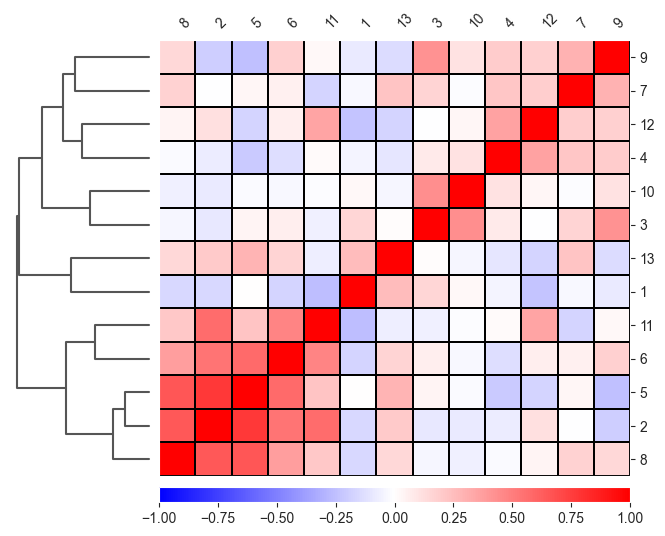

['Brain', 'Head mesenchyme', 'Surface ectoderm', 'Mesenchyme', 'Branchial arch', ..., 'AGM', 'Heart', 'Primitive gut tube', 'Spinal cord', 'Liver']
Length: 13
Categories (13, object): ['AGM', 'Brain', 'Branchial arch', 'Cavity', ..., 'Primitive gut tube', 'Sclerotome', 'Spinal cord', 'Surface ectoderm']
[2, 5, 12, 11, 6, ..., 8, 3, 1, 10, 4]
Length: 12
Categories (12, int64): [1, 2, 3, 4, ..., 10, 11, 12, 13]


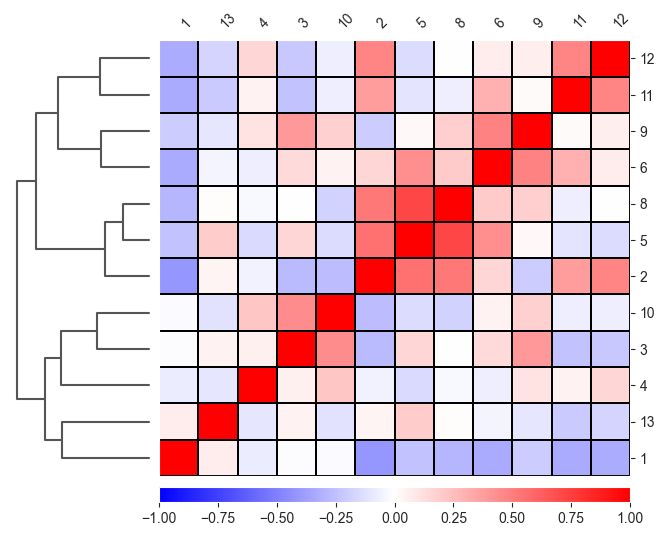

['Cavity', 'Spinal cord', 'Surface ectoderm', 'Mesenchyme', 'Sclerotome', ..., 'Head mesenchyme', 'Primitive gut tube', 'Liver', 'Connective tissue', 'Brain']
Length: 13
Categories (13, object): ['AGM', 'Brain', 'Cavity', 'Connective tissue', ..., 'Primitive gut tube', 'Sclerotome', 'Spinal cord', 'Surface ectoderm']
[2, 8, 12, 5, 9, ..., 3, 10, 6, 1, 11]
Length: 12
Categories (12, int64): [1, 2, 3, 4, ..., 10, 11, 12, 13]


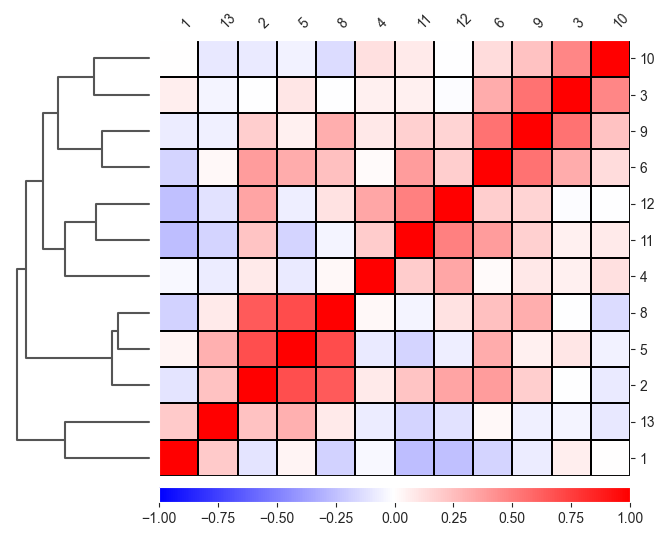

In [9]:
for adata_ in Batch_list:
    # correlation_matrix = pd.crosstab(adata_.obs['mclust'], adata_.obs['mclust'], normalize='all')
    print(adata_.obs['annotation'].unique())
    print(adata_.obs['mclust'].unique())
    sc.pl.correlation_matrix(adata_, groupby='mclust', figsize=(8,6), show=True)

In [5]:
#无法正确配置颜色

# # 检查并将 'mclust' 转换为字符串类型
# adata_1.obs['mclust'] = adata_1.obs['mclust'].astype(str)
# 
# # 选择目标聚类标签（假设目标空间域标签为 '1'）
# target_cluster = '1'
# 
# # 创建布尔掩码列，用于标记属于目标空间域的点
# adata_1.obs['is_target'] = (adata_1.obs['mclust'] == target_cluster)
# 
# # 使用布尔掩码设置颜色
# adata_1.obs['spatial_color'] = adata_1.obs['is_target'].map({True: '#ff521e', False: '#d2d7d7'})  # 红色和灰色
# # adata_1.obs['color'] = np.where(adata_1.obs['mclust'] == target_cluster, 'orange', 'lightgray')
# 
# # 确认颜色列是否正确生成
# print(adata_1.obs[['mclust', 'is_target', 'spatial_color']].head())
# 
# # 使用 sc.pl.spatial 绘图
# sc.pl.spatial(
#     adata_1,
#     img_key='hires',          # 确保背景图像键名正确
#     alpha_img=1.0,            # 背景透明度
#     color='spatial_color',    # 根据颜色列绘图
#     spot_size=2,            # 调整点大小
#     title=f"Spatial Domain {target_cluster}"  # 图像标题
# )


In [23]:
adata.obs['mclust'] = adata.obs['mclust'].astype(str)

In [41]:
sc.tl.rank_genes_groups(adata, 'mclust', groups=['11'], reference='1', key_added = "11vs1")
sc.tl.rank_genes_groups(adata, 'mclust', groups=['12'], reference='11', key_added = "12vs11")

In [42]:
cut_log2fc_min = 2

g_list1 = list(sc.get.rank_genes_groups_df(adata, group=['11'], key='11vs1', pval_cutoff=0.05, log2fc_min=cut_log2fc_min)['names'])
g_list1_filter = g_list1[0:20]
g_list2 = list(sc.get.rank_genes_groups_df(adata, group=['12'], key='12vs11', pval_cutoff=0.05, log2fc_min=cut_log2fc_min)['names'])
g_list2_filter = g_list2[0:20]

In [34]:
#差异分析

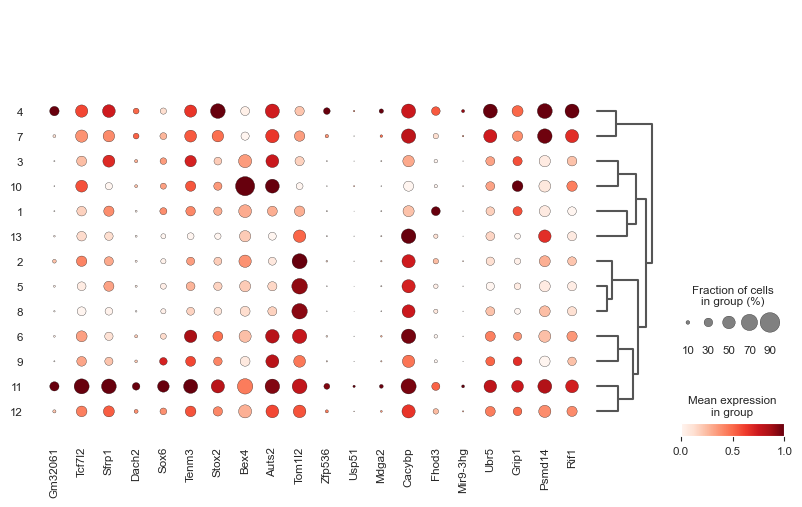

In [35]:
sc.pl.dotplot(adata, g_list1_filter, groupby='mclust', dendrogram=True, swap_axes=False, standard_scale='var', )

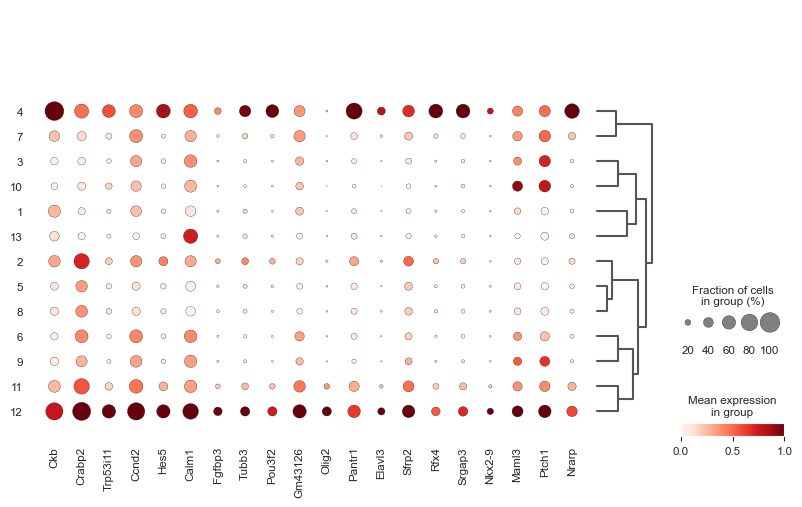

In [36]:
sc.pl.dotplot(adata, g_list2_filter, groupby='mclust', dendrogram=True, swap_axes=False, standard_scale='var', )

In [37]:
mg1 = ['Actc1', 'Myl2', 'Myl9', 'Igf2r', 'Slc2a1', 'mt-Nd2', 'Igf2', 'Thbs4']
mg2 = ['Hba-a1', 'Hba-a2', 'Nudt4', 'Gpx1', 'Hba-x', 'Cited2', 'Hbb-bh1', 'Slc25a5']

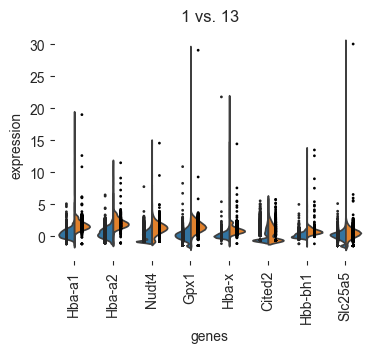

In [96]:
# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(4, 3))
# 设置坐标轴的位置
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
# 在坐标轴上绘制图形
sc.pl.rank_genes_groups_violin(adata, gene_names=mg, jitter=False, key='1vs13', size=2, ax=ax,save=False)

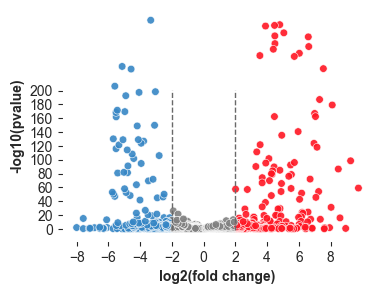

In [74]:
pvals_adj = [i[0] for i in adata.uns['1vs13']["pvals_adj"]]
pvals = [i[0] for i in adata.uns['1vs13']["pvals"]]
logfoldchanges = [i[0] for i in adata.uns['1vs13']["logfoldchanges"]]
import seaborn as sns  # Statistical visualization

result = pd.DataFrame()
result['x'] = logfoldchanges
result['y'] = -np.log10(pvals)
# result['pvals'] = pvals
# result['-log10(pvalue)']=-np.log10(logfoldchanges)

# 设置pvalue和logFC的阈值
# cut_off_pvalue = 0.0000001
cut_off_logFC = 2
# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(4, 3))
#分组为up, normal, down
result.loc[(result.x > cut_off_logFC), 'group'] = 'up'
result.loc[(result.x < -cut_off_logFC), 'group'] = 'down'
result.loc[(result.x >= -cut_off_logFC) & (result.x <= cut_off_logFC), 'group'] = 'normal'
result.loc[(result.x < -9),'x'] = -9.584669 + 2
#result.loc[(result.y > 200),'y'] = 170.884798 - 50
#绘制散点图
ax = sns.scatterplot(x="x", y="y",
                     ax=ax,
                     hue='group',
                     hue_order=('down', 'normal', 'up'),
                     palette=("#3686C5", "grey", "#FF1623"),  #palette=("#377EB8","grey","#E41A1C"),
                     alpha=0.9,
                     s=30,
                     legend=None,
                     data=result)

#确定坐标轴显示范围
# xmin=-2
# xmax=2
# ymin=0
# ymax=5

# ax.spines['right'].set_visible(False) #去掉右边框
# ax.spines['top'].set_visible(False) #去掉上边框
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# 
ax.vlines(-cut_off_logFC, -2, 201, color='dimgrey', linestyle='dashed', linewidth=1)  #画竖直线
ax.vlines(cut_off_logFC, -2, 201, color='dimgrey', linestyle='dashed', linewidth=1)  #画竖直线
# # ax.hlines(-np.log10(cut_off_pvalue), xmin, xmax, color='dimgrey',linestyle='dashed', linewidth=1) #画竖水平线
ax.set_xticks(range(-8, 10, 2))  # 设置x轴刻度
ax.set_yticks(range(0, 201, 20))  # 设置y轴刻度
ax.set_ylabel('-log10(pvalue)', fontweight='bold')  # 设置y轴标签
ax.set_xlabel('log2(fold change)', fontweight='bold')  # 设置x轴标签
ax.grid(False)
plt.savefig('./huoshantu_a.pdf')

In [43]:
#富集
import gseapy

enr_res1 = gseapy.enrichr(gene_list=g_list1,
                         organism='Mouse',
                         gene_sets='GO_Biological_Process_2023',
                         cutoff=0.5)
enr_res1.results.head()

enr_res2 = gseapy.enrichr(gene_list=g_list2,
                         organism='Mouse',
                         gene_sets='GO_Biological_Process_2023',
                         cutoff=0.5)
enr_res2.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Negative Regulation Of Endothelial Cell Migrat...,4/37,0.000019,0.009962,0,0,29.388027,319.660383,NOTCH1;SLIT2;VASH1;ADAMTS9
1,GO_Biological_Process_2023,Notch Signaling Pathway (GO:0007219),4/40,0.000026,0.009962,0,0,26.934959,284.493896,NOTCH1;NRARP;MAML3;HES5
2,GO_Biological_Process_2023,Neuron Development (GO:0048666),6/150,0.000046,0.011508,0,0,10.296875,102.790671,ROBO2;BTG2;NOVA2;STMN2;STMN4;POU3F2
3,GO_Biological_Process_2023,Pulmonary Valve Morphogenesis (GO:0003184),3/18,0.000060,0.011508,0,0,47.949398,466.300260,ROBO2;NOTCH1;SLIT2
4,GO_Biological_Process_2023,Pulmonary Valve Development (GO:0003177),3/20,0.000083,0.011628,0,0,42.304040,397.517861,ROBO2;NOTCH1;SLIT2


<AxesSubplot: title={'center': '11vs1'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

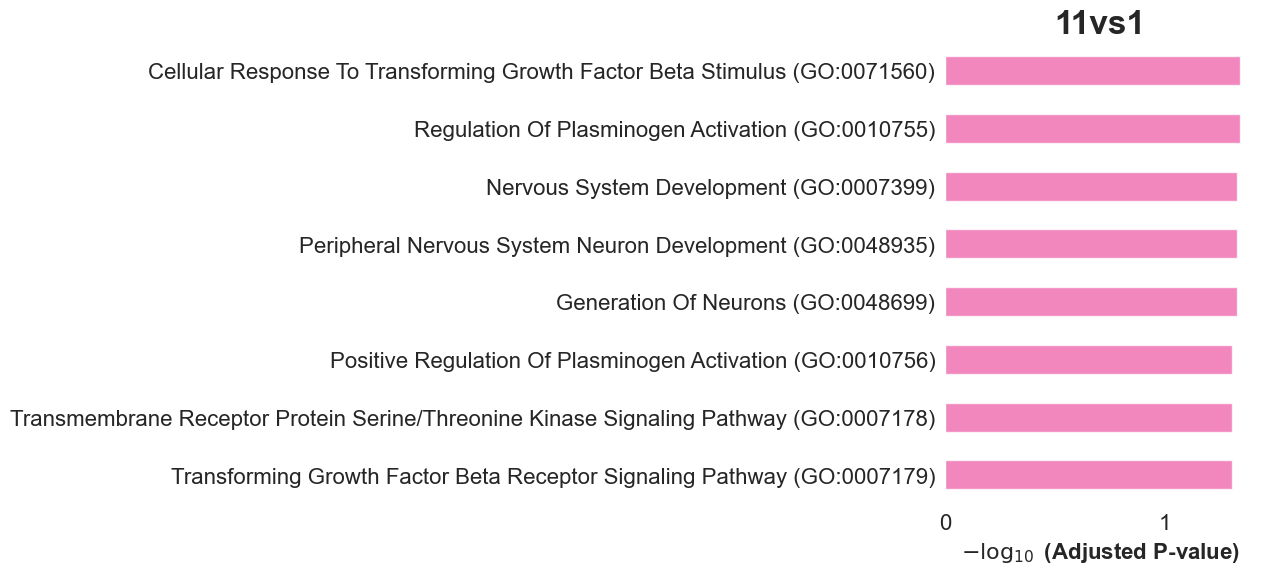

In [48]:
gseapy.barplot(enr_res1.res2d,title='11vs1',color='#ed5fa7')

<AxesSubplot: title={'center': '12vs11'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

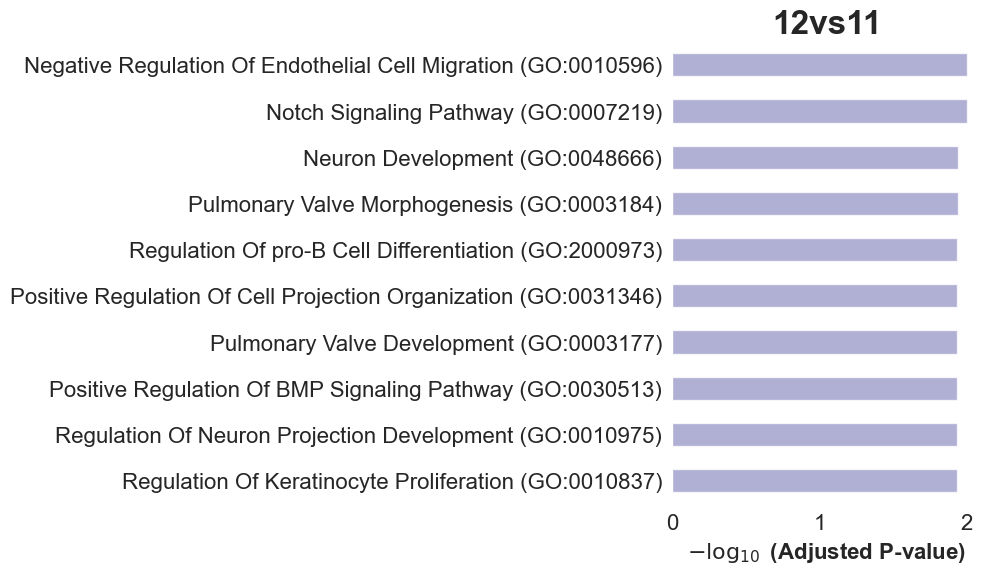

In [47]:
gseapy.barplot(enr_res2.res2d,title='12vs11',color='#9694c6')

In [19]:
adata.obs['mclust'] = adata.obs['mclust'].astype(str)

sc.tl.rank_genes_groups(adata, 'mclust', groups=['8'], reference='2', key_added="8vs2")

cut_log2fc_min = 2

g_list = list(
    sc.get.rank_genes_groups_df(adata, group=['8'], key='8vs2', pval_cutoff=0.05, log2fc_min=cut_log2fc_min)['names'])

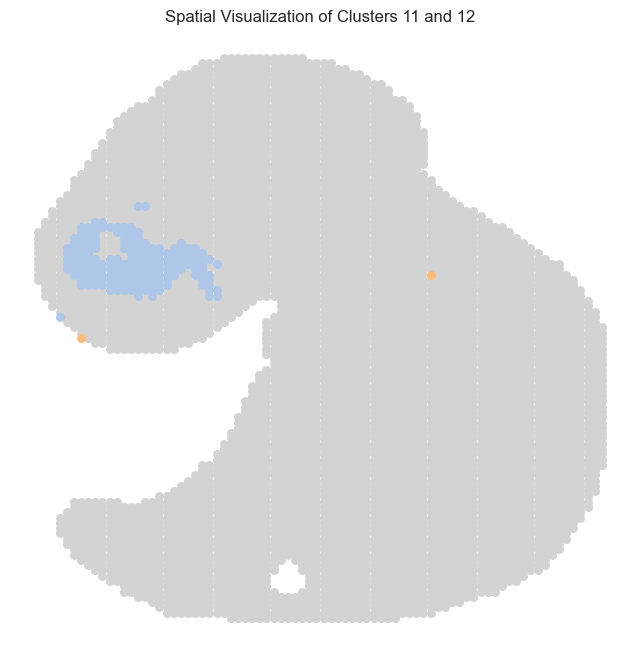

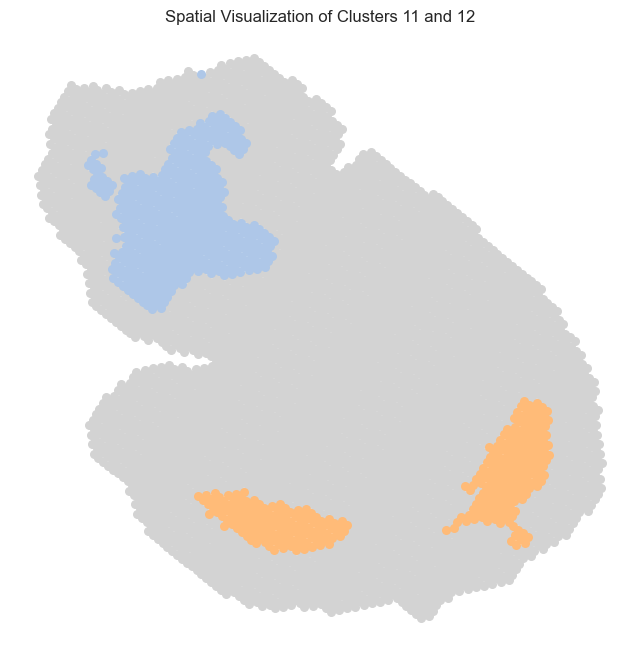

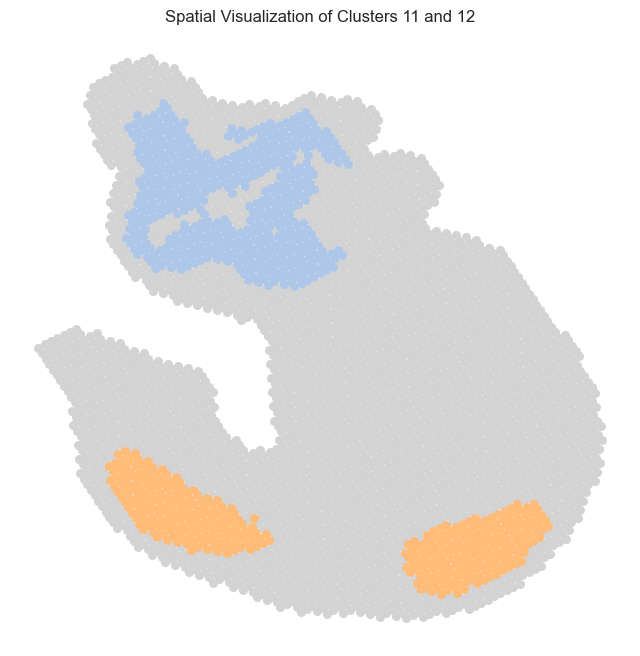

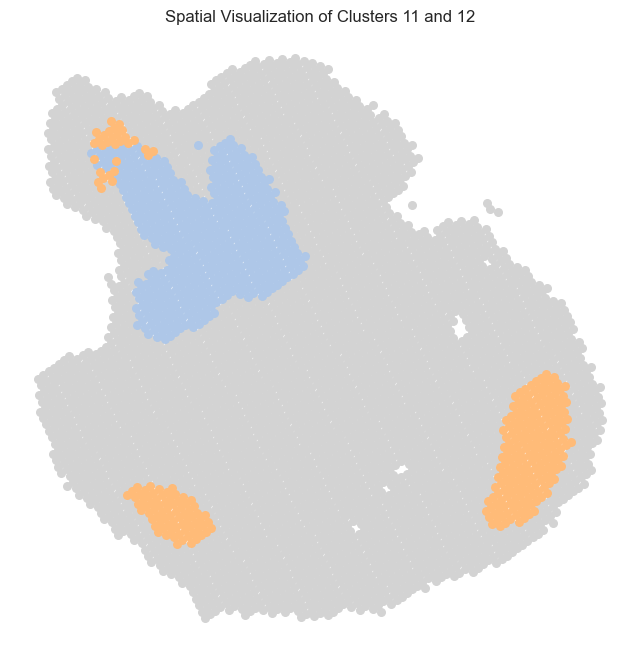

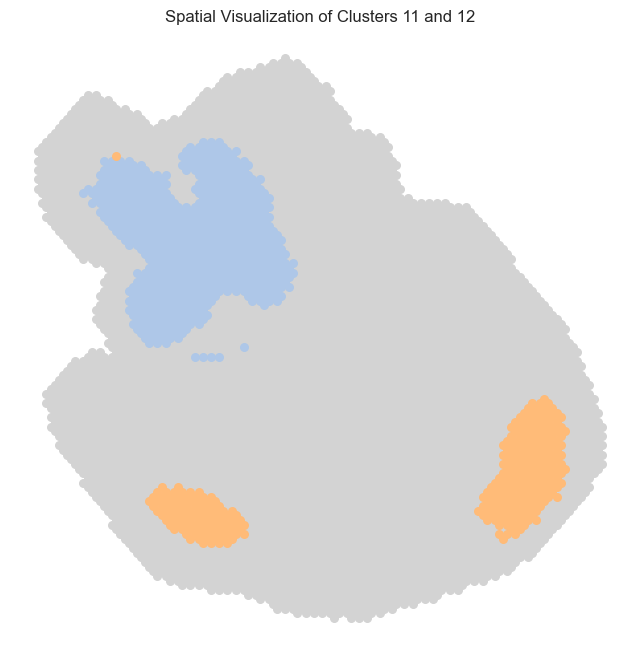

In [20]:
#空间域可视化
for adata_n in Batch_list: 
    # 获取坐标信息
    x = adata_n.obsm['spatial'][:, 0]  # X坐标
    y = adata_n.obsm['spatial'][:, 1]  # Y坐标
    
    # 获取聚类信息
    cluster_labels = adata_n.obs['mclust'].astype(str)
    
    # 选择目标空间域 (例如，聚类标签为 '1' 和 '2')
    target_cluster_1 = '11'
    target_cluster_2 = '12'
    
    # 创建布尔掩码
    is_target_1 = cluster_labels == target_cluster_1
    is_target_2 = cluster_labels == target_cluster_2
    
    # 绘图
    plt.figure(figsize=(8, 8))
    
    # 绘制背景 (不是目标空间域的点)
    plt.scatter(x[~is_target_1 & ~is_target_2], y[~is_target_1 & ~is_target_2], c='lightgray', s=30, label='Background', alpha=1.)
    
    # 绘制目标空间域 1 (标签为 1 的点)
    plt.scatter(x[is_target_1], y[is_target_1], c='#aec7e8', s=30, label=f'Cluster {target_cluster_1}', alpha=1.)
    
    # 绘制目标空间域 2 (标签为 2 的点)
    plt.scatter(x[is_target_2], y[is_target_2], c='#ffbb78', s=30, label=f'Cluster {target_cluster_2}', alpha=1.)
    
    # 反转Y轴 (符合空间转录组学的显示习惯)
    plt.gca().invert_yaxis()
    
    # 添加图例和标题
    #plt.legend()
    plt.title(f"Spatial Visualization of Clusters {target_cluster_1} and {target_cluster_2}")
    plt.axis('off')  # 去除坐标轴
    plt.show()

True


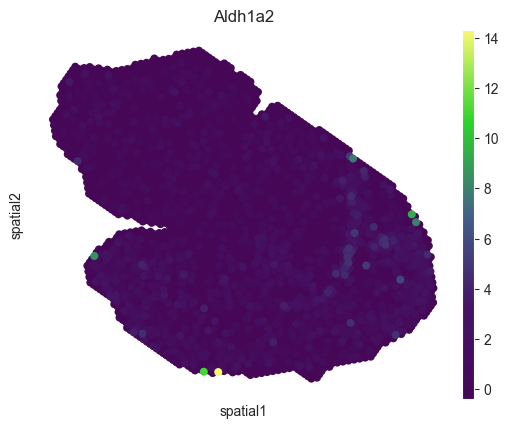

True


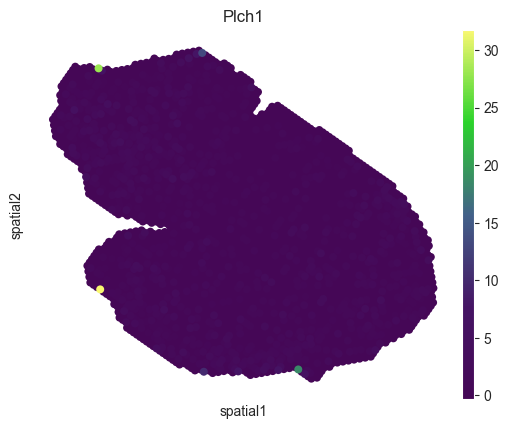

True


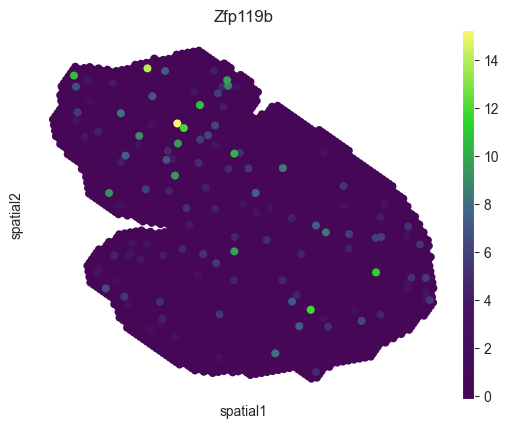

True


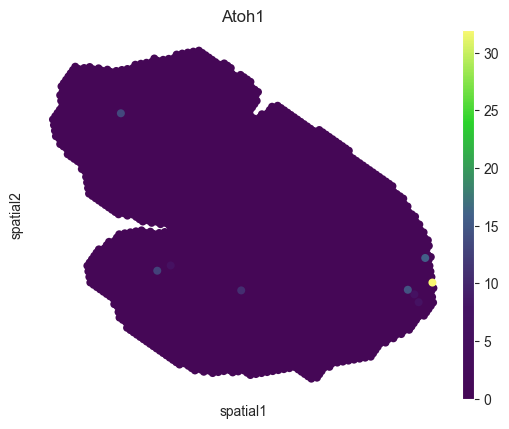

True


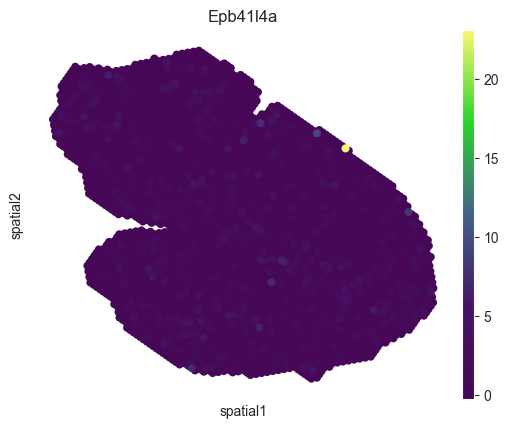

True


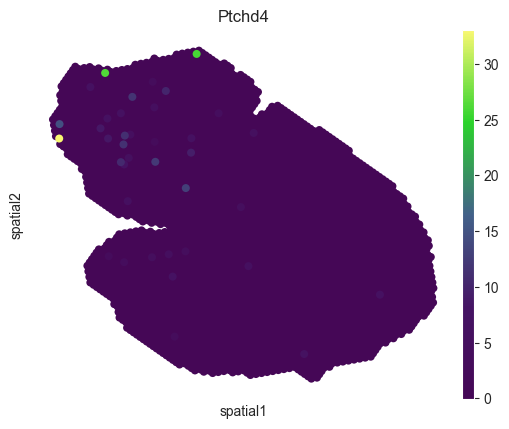

True


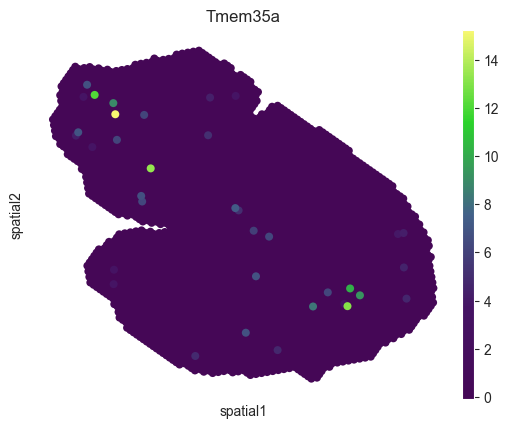

True


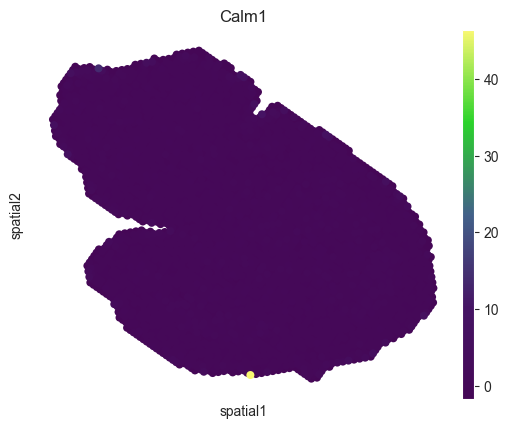

True


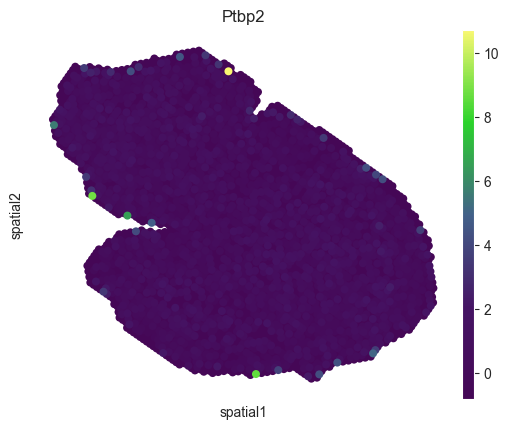

True


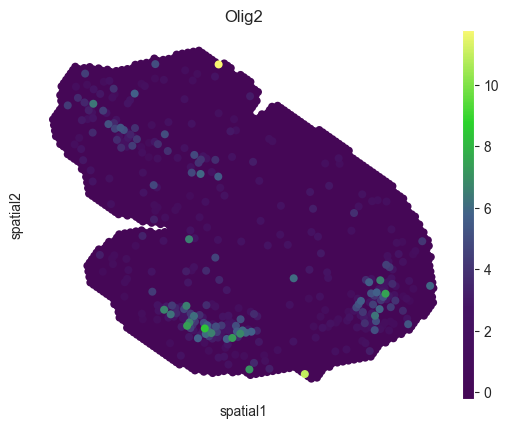

True


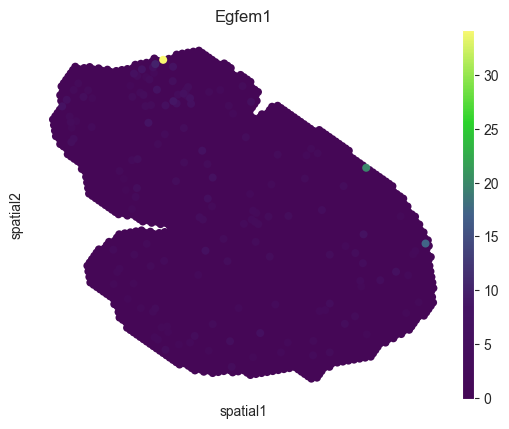

True


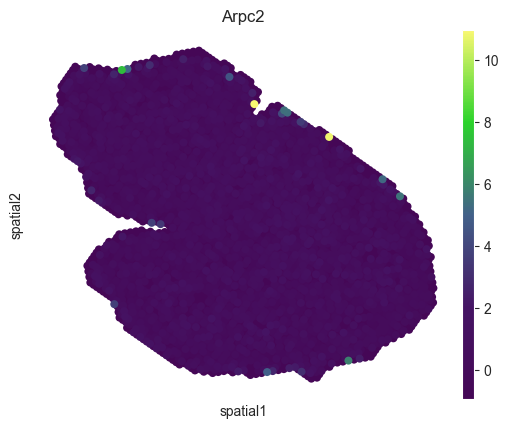

True


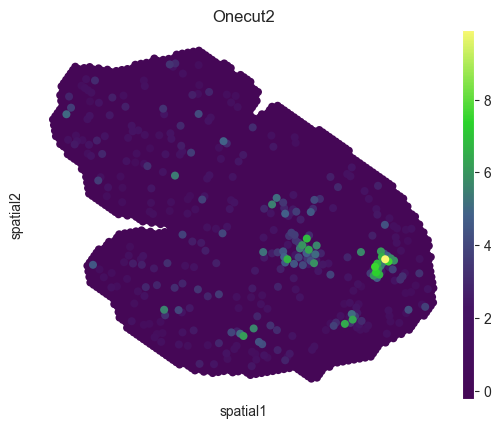

True


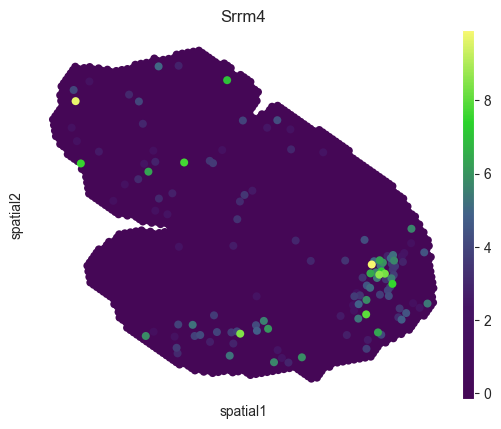

True


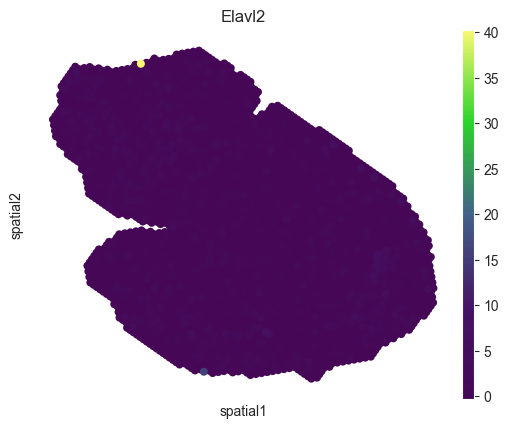

True


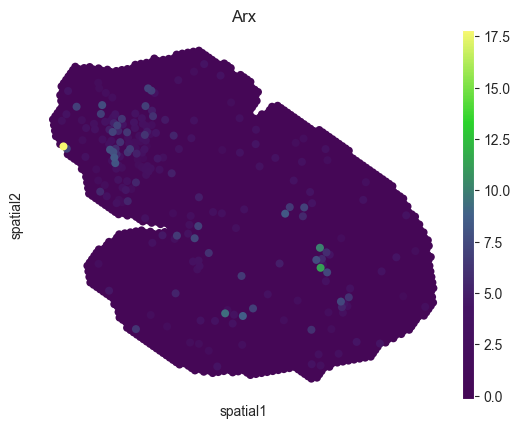

True


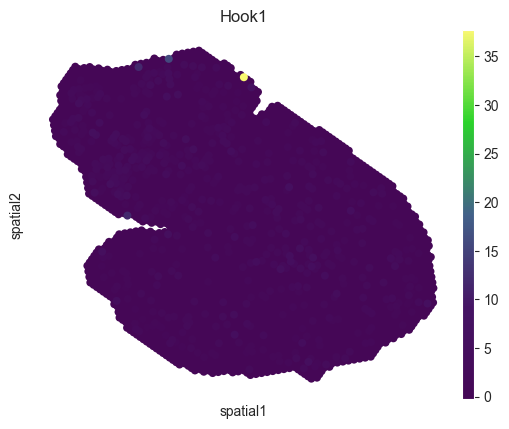

True


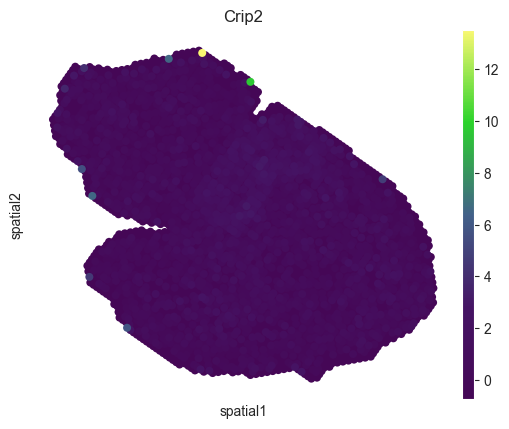

True


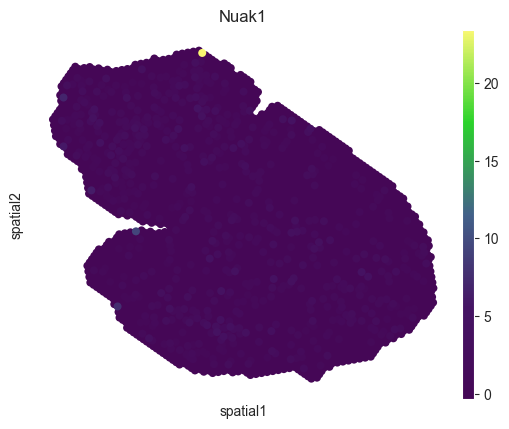

True


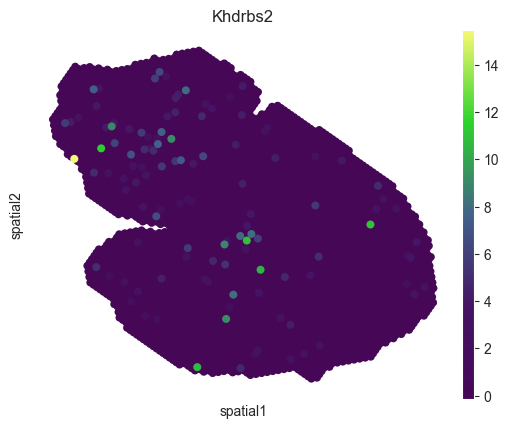

True


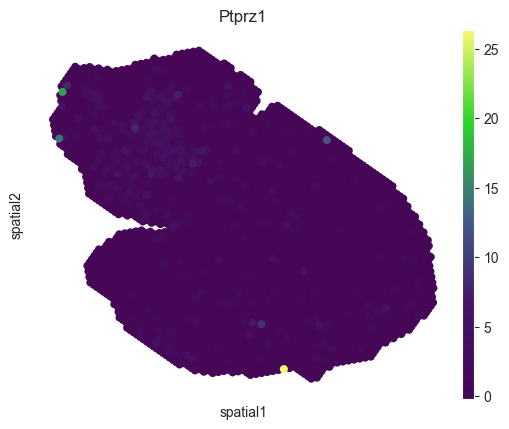

True


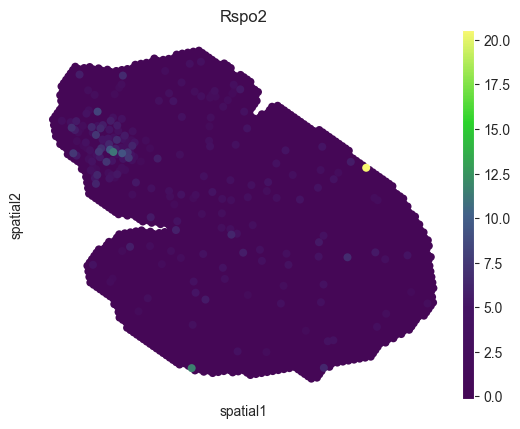

True


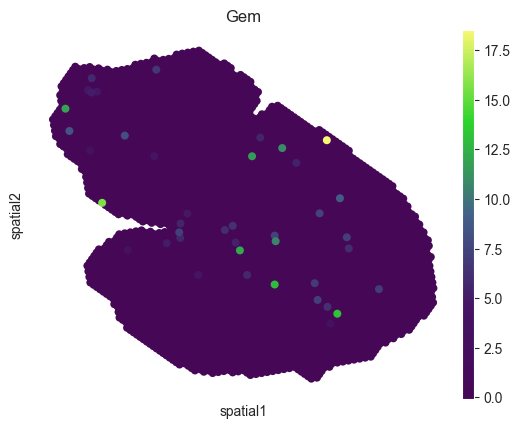

True


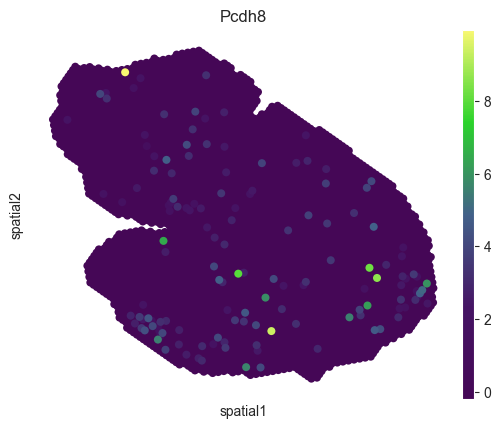

True


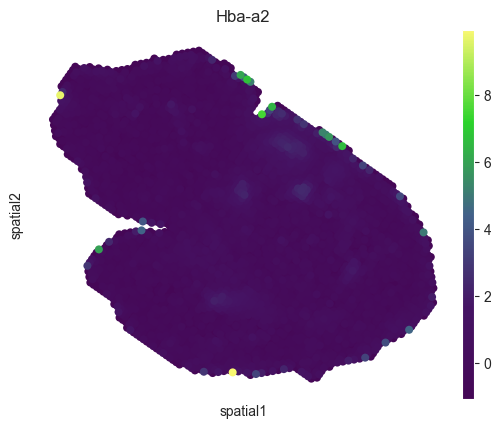

True


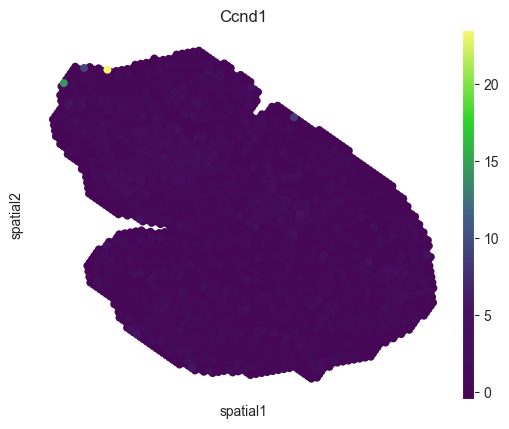

True


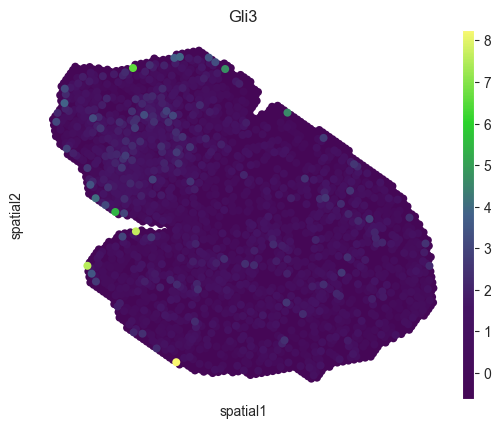

True


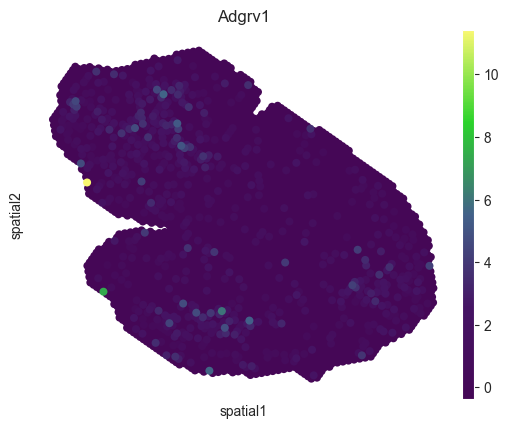

True


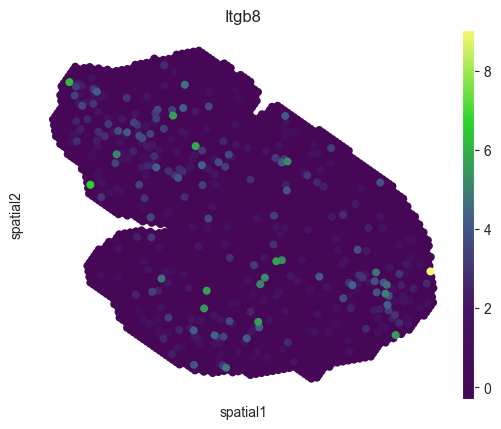

True


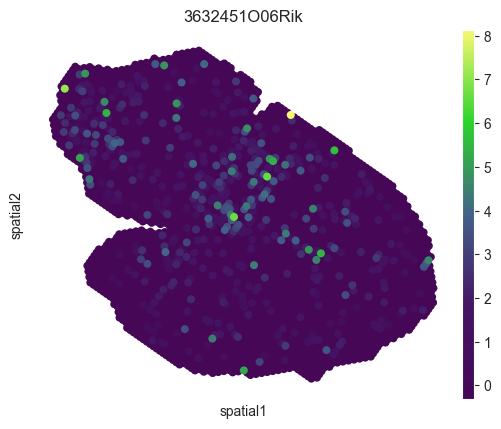

True


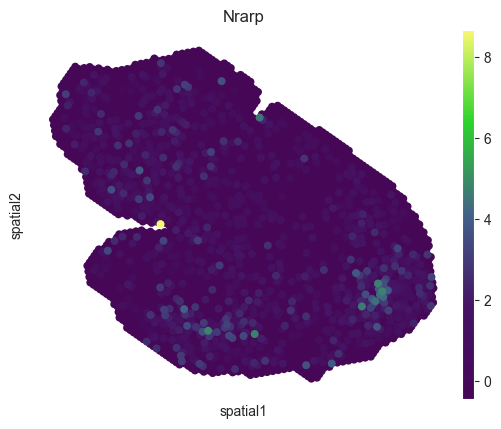

True


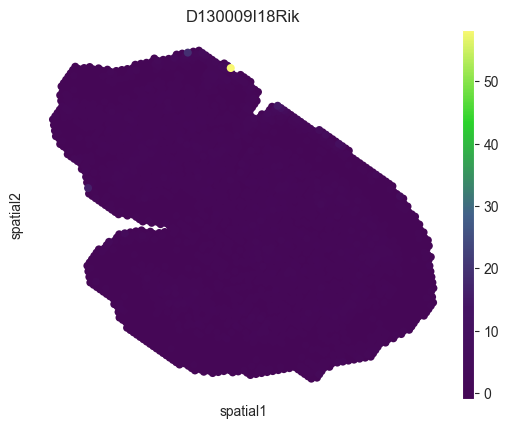

True


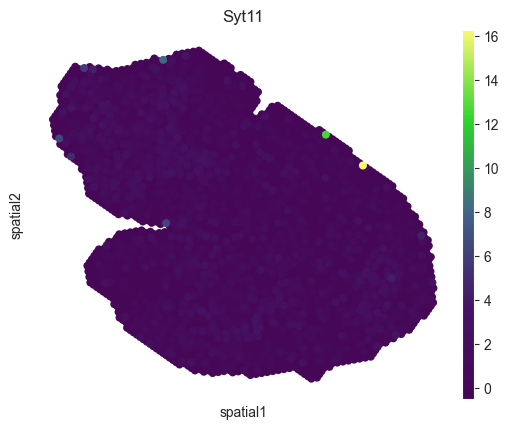

In [20]:
#基因可视化
import matplotlib.colors as clr

#gene_list = ['Pgrmc1']

color_self = clr.LinearSegmentedColormap.from_list('pink_green',
                                                   ['#450756', '#451464', '#426189', '#2BD32B', '#F9F871'], N=256)

adata_tmp = adata[adata.obs['batch_name'] == 'E9.5_E2S1.MOSTA']
for gene_raw in g_list:
    print(gene_raw in adata_tmp.var.index)  # 检查基因是否存在
    idx = adata_tmp.var.index.tolist().index(gene_raw)  #输出基因的idx
    adata_tmp.obs[f'{gene_raw}(raw)'] = np.array(adata_tmp.X[:, idx]) # 稀疏矩阵转为密集矩阵
    sc_ = sc.pl.spatial(adata_tmp, img_key="hires",
                        color=f'{gene_raw}(raw)',
                        title=gene_raw,
                        color_map=color_self,
                        spot_size=2)